# Data Sanity Check


--- Running Data Sanity Check ---
Daily data loaded successfully.

Total days in window (all years): 810
Wet days (>1.0mm): 703
WET DAY PERCENTAGE: 86.79%


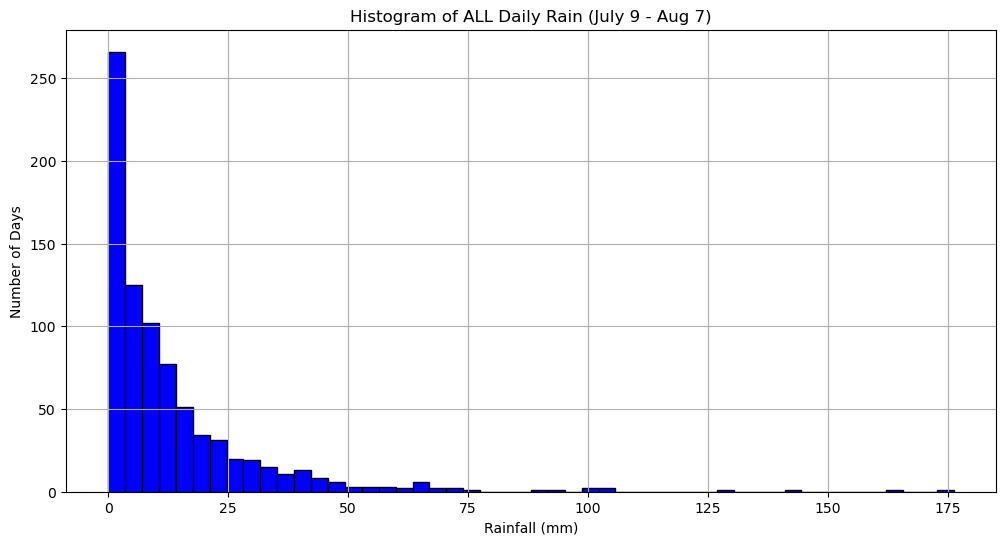

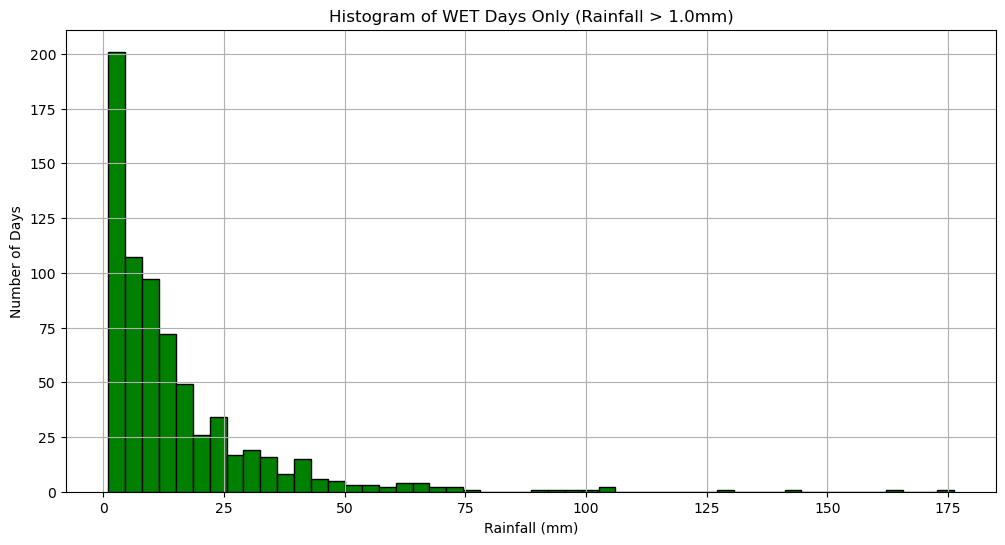

In [6]:
# -------------------------------------------------------------------
# DATA SANITY CHECK SCRIPT
# -------------------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Define File Names and Parameters ---
DAILY_RAIN_FILE = 'kanker_daily_rain_1997-2024.csv'
DATE_COLUMN_NAME = 'Date' 
RAIN_THRESHOLD = 1.0 # The threshold we used

# --- Window Parameters (from Step 3) ---
N_DAYS = 30
START_MONTH = 7
START_DAY = 9

print("--- Running Data Sanity Check ---")

# --- 1. Load Data (with corrected date parsing) ---
try:
    rain_df = pd.read_csv(DAILY_RAIN_FILE)
    rain_df = rain_df.rename(columns={DATE_COLUMN_NAME: 'Date', 'Mean_Rainfall_mm': 'Rainfall'})
    try:
        rain_df['Date'] = pd.to_datetime(rain_df['Date'], dayfirst=True)
    except Exception:
        rain_df['Date'] = pd.to_datetime(rain_df['Date'])
    rain_df = rain_df.dropna(subset=['Rainfall'])
    print("Daily data loaded successfully.")
except Exception as e:
    print(f"Error loading data: {e}")

# --- 2. Isolate Seasonal Data ---
window_mask = (rain_df['Date'].dt.month == 7) & (rain_df['Date'].dt.day >= 9) | \
              (rain_df['Date'].dt.month == 8) & (rain_df['Date'].dt.day <= 7)
seasonal_df = rain_df[window_mask].copy()

# --- 3. Check Wet Day Percentage ---
total_days = len(seasonal_df)
wet_days_count = (seasonal_df['Rainfall'] > RAIN_THRESHOLD).sum()
wet_day_perc = (wet_days_count / total_days) * 100

print(f"\nTotal days in window (all years): {total_days}")
print(f"Wet days (>{RAIN_THRESHOLD}mm): {wet_days_count}")
print(f"WET DAY PERCENTAGE: {wet_day_perc:.2f}%")

# --- 4. Plot 1: Histogram of ALL Seasonal Rain ---
# This shows us the "zero" values vs. "rain" values
plt.figure(figsize=(12, 6))
plt.hist(seasonal_df['Rainfall'], bins=50, color='blue', edgecolor='black')
plt.title('Histogram of ALL Daily Rain (July 9 - Aug 7)')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Number of Days')
plt.grid(True)
plt.show()

# --- 5. Plot 2: Histogram of ONLY WET Days ---
# This shows us what the Gamma distribution is trying to fit
wet_data = seasonal_df[seasonal_df['Rainfall'] > RAIN_THRESHOLD]['Rainfall']
plt.figure(figsize=(12, 6))
plt.hist(wet_data, bins=50, color='green', edgecolor='black')
plt.title(f'Histogram of WET Days Only (Rainfall > {RAIN_THRESHOLD}mm)')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Number of Days')
plt.grid(True)
plt.show()

# Rain Threshold Finder


In [7]:
# -------------------------------------------------------------------
# NEW THRESHOLD FINDER SCRIPT
# -------------------------------------------------------------------
import pandas as pd
import numpy as np

# --- 1. Define File Names and Parameters ---
DAILY_RAIN_FILE = 'kanker_daily_rain_1997-2024.csv'
DATE_COLUMN_NAME = 'Date' 

# --- 2. Window Parameters ---
START_MONTH = 7
START_DAY = 9
END_MONTH = 8
END_DAY = 7

print("--- Running New Threshold Finder ---")

# --- 3. Load Data ---
try:
    rain_df = pd.read_csv(DAILY_RAIN_FILE)
    rain_df = rain_df.rename(columns={DATE_COLUMN_NAME: 'Date', 'Mean_Rainfall_mm': 'Rainfall'})
    try:
        rain_df['Date'] = pd.to_datetime(rain_df['Date'], dayfirst=True)
    except Exception:
        rain_df['Date'] = pd.to_datetime(rain_df['Date'])
    rain_df = rain_df.dropna(subset=['Rainfall'])
    print("Daily data loaded successfully.")
except Exception as e:
    print(f"Error loading data: {e}")

# --- 4. Isolate Seasonal Data ---
window_mask = (rain_df['Date'].dt.month == START_MONTH) & (rain_df['Date'].dt.day >= START_DAY) | \
              (rain_df['Date'].dt.month == END_MONTH) & (rain_df['Date'].dt.day <= END_DAY)
seasonal_df = rain_df[window_mask].copy()

# --- 5. Analyze Rainfall Distribution ---
# First, let's get *only* the days with *any* rain (Rainfall > 0)
rainy_days_data = seasonal_df[seasonal_df['Rainfall'] > 0]['Rainfall']

print(f"\nTotal seasonal days (July 9 - Aug 7): {len(seasonal_df)}")
print(f"Total days with ANY rain (Rain > 0): {len(rainy_days_data)}")

# --- 6. Calculate Percentile-Based Thresholds ---
# This will show us the distribution of the "rainy" days
p10 = np.percentile(rainy_days_data, 10)
p20 = np.percentile(rainy_days_data, 20)
p25 = np.percentile(rainy_days_data, 25)
p30 = np.percentile(rainy_days_data, 30)
p50 = np.percentile(rainy_days_data, 50) # The median

print("\n--- Percentiles for 'Rainy' Days (Rain > 0) ---")
print(f"  10th percentile (p10): {p10:.2f} mm")
print(f"  20th percentile (p20): {p20:.2f} mm")
print(f"  25th percentile (p25): {p25:.2f} mm")
print(f"  30th percentile (p30): {p30:.2f} mm")
print(f"  50th percentile (Median): {p50:.2f} mm")

print("\n--- RECOMMENDATION ---")
print("To separate 'trace rain' from 'real rain', choose a threshold from this list.")
print(f"For example, if p25 = 4.8 mm, this means 25% of all 'rainy' days")
print("are just 'drizzle' (less than 4.8 mm).")
print(f"Let's try using the 25th percentile ({p25:.2f} mm) as our new RAIN_THRESHOLD.")

--- Running New Threshold Finder ---
Daily data loaded successfully.

Total seasonal days (July 9 - Aug 7): 810
Total days with ANY rain (Rain > 0): 790

--- Percentiles for 'Rainy' Days (Rain > 0) ---
  10th percentile (p10): 0.83 mm
  20th percentile (p20): 1.90 mm
  25th percentile (p25): 2.49 mm
  30th percentile (p30): 3.36 mm
  50th percentile (Median): 7.96 mm

--- RECOMMENDATION ---
To separate 'trace rain' from 'real rain', choose a threshold from this list.
For example, if p25 = 4.8 mm, this means 25% of all 'rainy' days
are just 'drizzle' (less than 4.8 mm).
Let's try using the 25th percentile (2.49 mm) as our new RAIN_THRESHOLD.


# HBA

In [2]:
# -------------------------------------------------------------------
# CHAPTER 3.3.1: MODEL 1 - HISTORICAL BURN ANALYSIS (HBA)
# -------------------------------------------------------------------
import pandas as pd
import numpy as np

# --- 1. Define File Names and Parameters ---
FINAL_INDEX_FILE = 'final_index_series.csv'

# --- Derivative Parameters ---
# We will set the strikes based on the data, as defined in our methodology
STRIKE_K1_PERCENTILE = 0.30  # 30th percentile (Drought)
STRIKE_K2_PERCENTILE = 0.90  # 90th percentile (Flood)

TICK_VALUE = 1000  # Rs.1000 per mm of deviation
DISCOUNT_RATE = 0.065  # 6.5% annual risk-free rate (example)
# Critical window July 9th to Aug 7th. Maturity date should technically be Aug 7th. Assume pricing date to be 1 year before?  
TIME_TO_MATURITY_T = 1 

print("Parameters set.")

# --- 2. Load the Final Index Data ---
print(f"Loading final index data from: {FINAL_INDEX_FILE}...")
try:
    index_df = pd.read_csv(FINAL_INDEX_FILE)
    # We will use the 'Index_Value_mm' column
    R = index_df['Index_Value_mm']
    print("Data loaded successfully.")
    print(f"Loaded {len(R)} years of index data.")
except FileNotFoundError:
    print(f"--- ERROR: File not found: {FINAL_INDEX_FILE} ---")
except KeyError:
    print(f"--- ERROR: Column 'Index_Value_mm' not found in file. ---")

# --- 3. Define Strikes ---
# Calculate the strike levels from the historical data
K1_drought_strike = np.percentile(R, STRIKE_K1_PERCENTILE * 100)
K2_flood_strike = np.percentile(R, STRIKE_K2_PERCENTILE * 100)

print(f"\nCalculating strikes based on {len(R)} years of data...")
print(f"  Lower Strike (K1) at {STRIKE_K1_PERCENTILE*100}th percentile: {K1_drought_strike:.2f} mm")
print(f"  Upper Strike (K2) at {STRIKE_K2_PERCENTILE*100}th percentile: {K2_flood_strike:.2f} mm")

# --- 4. Calculate Historical Payoffs (Vectorized) ---
# 
print("Calculating historical payoffs for each year...")

# Payoff = [max(K1 - R, 0) + max(R - K2, 0)] * Tick
payoff_drought = np.maximum(K1_drought_strike - R, 0)
payoff_flood = np.maximum(R - K2_flood_strike, 0)

# The total payoff is the sum of the two
historical_payoffs = (payoff_drought + payoff_flood) * TICK_VALUE

# Add this to our dataframe to see the results
index_df['Historical_Payoff'] = historical_payoffs

print("Payoff calculation complete.")
print("\nDataFrame with calculated historical payoffs:")
print(index_df)

# --- 5. Calculate the Final HBA Price ---
# The HBA price is the simple average of all historical payoffs...
average_payoff = historical_payoffs.mean()

# ...discounted to present value.
hba_price = average_payoff * np.exp(-DISCOUNT_RATE * TIME_TO_MATURITY_T)

# --- 6. Final Result ---
print("\n--- !!! FINAL HBA PRICING RESULT !!! ---")
print(f"  Average Historical Payoff (Expected Loss): Rs.{average_payoff:.2f}")
print(f"  Discounted HBA Price (Actuarial Premium): Rs.{hba_price:.2f}")

Parameters set.
Loading final index data from: final_index_series.csv...
Data loaded successfully.
Loaded 25 years of index data.

Calculating strikes based on 25 years of data...
  Lower Strike (K1) at 30.0th percentile: 313.13 mm
  Upper Strike (K2) at 90.0th percentile: 572.55 mm
Calculating historical payoffs for each year...
Payoff calculation complete.

DataFrame with calculated historical payoffs:
    Year  Index_Value_mm  Historical_Payoff
0   1998      302.446112       10686.392404
1   1999      364.210995           0.000000
2   2000      308.890435        4242.069180
3   2001      435.131085           0.000000
4   2002      204.792493      108340.011052
5   2003      548.448104           0.000000
6   2004      377.376597           0.000000
7   2005      357.258497           0.000000
8   2006      588.623738       16070.253926
9   2007      398.410458           0.000000
10  2008      317.588911           0.000000
11  2009      339.620095           0.000000
12  2010      543.96

# GLM

In [2]:
# -------------------------------------------------------------------
# CHAPTER 3.3.2: MODEL 2 - GENERALIZED LINEAR MODEL (GLM) (Corrected)
# -------------------------------------------------------------------
import pandas as pd
import numpy as np
import statsmodels.api as sm
from datetime import timedelta
import time

start_time = time.time()

# --- 1. Define File Names and Parameters ---
DAILY_RAIN_FILE = 'kanker_daily_rain_1997-2024.csv'
DATE_COLUMN_NAME = 'Date' # The date column in your rain CSV

# --- Derivative Parameters (from HBA) ---
K1_drought_strike = 313.13  # (30th percentile from your HBA output)
K2_flood_strike = 572.55  # (90th percentile from your HBA output)
TICK_VALUE = 1000         # Rs. 1000 per mm
DISCOUNT_RATE = 0.065     # 6.5%
TIME_TO_MATURITY_T = 1    # 1 Year

# --- Window Parameters (from Step 3) ---
N_DAYS = 30
START_MONTH = 7
START_DAY = 9

# --- Simulation Parameters ---
N_SIMULATIONS = 10000

print("Parameters set. Loading daily rainfall data...")

# --- 2. Load and Prepare Daily Rainfall Data ---
try:
    rain_df = pd.read_csv(DAILY_RAIN_FILE, parse_dates=[DATE_COLUMN_NAME])
    rain_df = rain_df.rename(columns={DATE_COLUMN_NAME: 'Date', 'Mean_Rainfall_mm': 'Rainfall'})
    rain_df = rain_df.dropna(subset=['Rainfall']) # Drop any NaN days
except FileNotFoundError:
    print(f"--- ERROR: File not found: {DAILY_RAIN_FILE} ---")
except KeyError:
    print(f"--- ERROR: Column '{DATE_COLUMN_NAME}' not found. ---")

# --- 3. Feature Engineering for Seasonality ---
rain_df['Date'] = pd.to_datetime(rain_df['Date'], dayfirst=True)
rain_df['day_of_year'] = rain_df['Date'].dt.dayofyear
rain_df['sin_day'] = np.sin(2 * np.pi * rain_df['day_of_year'] / 365.25)
rain_df['cos_day'] = np.cos(2 * np.pi * rain_df['day_of_year'] / 365.25)

# --- 4. Prepare Data for the Two-Part Model ---
# Part 1: Frequency (wet vs. dry)
rain_df['is_wet'] = (rain_df['Rainfall'] > 0).astype(int)

# Part 2: Severity (amount of rain, given it is wet)
wet_days_df = rain_df[rain_df['is_wet'] == 1].copy()
wet_days_df['Rainfall_wet'] = wet_days_df['Rainfall']

print(f"Data prepared. {len(rain_df)} total days, {len(wet_days_df)} wet days.")

# --- 5. Fit Model 1: Frequency (Logistic GLM) ---
print("Fitting Frequency model (Logistic GLM)...")
# X = The predictors (seasonality)
# --- THIS IS THE CORRECTED LINE ---
# We must use the full 'rain_df' for both X and y
X_freq = rain_df[['sin_day', 'cos_day']] 
# --- END CORRECTION ---
X_freq = sm.add_constant(X_freq, prepend=False) # Add an intercept term
# y = The target (wet or dry)
y_freq = rain_df['is_wet']

# Fit the GLM with a Binomial (Logistic) family
# This should work now as X_freq and y_freq have the same length and index
freq_model = sm.GLM(y_freq, X_freq, family=sm.families.Binomial()).fit()
print(freq_model.summary())

# --- 6. Fit Model 2: Severity (Gamma GLM) ---
# This part was already correct
print("\nFitting Severity model (Gamma GLM)...")
# X = The predictors (seasonality, using only wet days)
X_sev = wet_days_df[['sin_day', 'cos_day']]
X_sev = sm.add_constant(X_sev, prepend=False)
# y = The target (how much rain, given it was wet)
y_sev = wet_days_df['Rainfall_wet']

# Fit the GLM with a Gamma family and a 'log' link
sev_model = sm.GLM(y_sev, X_sev, family=sm.families.Gamma(link=sm.families.links.log())).fit()
print(sev_model.summary())

# --- 7. Prepare for Simulation ---
print("\nSetting up Monte Carlo simulation...")
win_start = pd.Timestamp(year=2000, month=START_MONTH, day=START_DAY)
win_end = win_start + timedelta(days=N_DAYS - 1)
window_dates = pd.date_range(start=win_start, end=win_end)

X_pred = pd.DataFrame({'day_of_year': window_dates.dayofyear})
X_pred['sin_day'] = np.sin(2 * np.pi * X_pred['day_of_year'] / 365.25)
X_pred['cos_day'] = np.cos(2 * np.pi * X_pred['day_of_year'] / 365.25)
X_pred = sm.add_constant(X_pred.drop(columns=['day_of_year']), prepend=False)

gamma_scale = sev_model.scale



# --- 8. Run the Monte Carlo Simulation (Corrected) ---
print(f"Running {N_SIMULATIONS} simulations...")
simulated_payoffs = []

# --- THIS IS THE CHATBOT'S CORRECTED LOGIC ---
# Get the constant dispersion (phi) from the fitted model
phi_dispersion = float(sev_model.scale)
# The shape (k) is constant
gamma_shape_k = 1.0 / phi_dispersion
# ---

for _ in range(N_SIMULATIONS):
    # --- Model 1: Simulate Frequency ---
    prob_wet = freq_model.predict(X_pred)
    is_wet_sim = np.random.binomial(1, prob_wet)
    
    # --- Model 2: Simulate Severity ---
    # Predict the mean (mu) for each of the 30 days
    mu_wet = sev_model.predict(X_pred)
    
    # --- THIS IS THE CHATBOT'S CORRECTED LOGIC ---
    # The scale (theta) varies with the mean: theta = mu * phi
    gamma_scale_theta = mu_wet * phi_dispersion
    
    # Simulate 30 rain amounts using the varying scale
    amount_sim = np.random.gamma(shape=gamma_shape_k, scale=gamma_scale_theta)
    # ---
    
    # --- Combine ---
    daily_rain_sim = is_wet_sim * amount_sim
    R_sim = daily_rain_sim.sum()
    
    # --- Calculate Payoff ---
    payoff_drought = np.maximum(K1_drought_strike - R_sim, 0)
    payoff_flood = np.maximum(R_sim - K2_flood_strike, 0)
    total_payoff = (payoff_drought + payoff_flood) * TICK_VALUE
    
    simulated_payoffs.append(total_payoff)

print("Simulation complete.")


# --- 9. Calculate the Final GLM Price ---
average_payoff_glm = np.mean(simulated_payoffs)
glm_price = average_payoff_glm * np.exp(-DISCOUNT_RATE * TIME_TO_MATURITY_T)

print(f"\n--- Model 1 (HBA) vs. Model 2 (GLM) ---")
print(f"  Discounted HBA Price: Rs.{25336.50:,.2f}") # From your HBA run
print(f"  Discounted GLM Price: Rs.{glm_price:,.2f}")
print(f"  (Based on {N_SIMULATIONS} simulations)")

end_time = time.time()
print(f"\nTotal time taken: {end_time - start_time:.2f} seconds")

Parameters set. Loading daily rainfall data...
Data prepared. 9861 total days, 4340 wet days.
Fitting Frequency model (Logistic GLM)...
                 Generalized Linear Model Regression Results                  
Dep. Variable:                 is_wet   No. Observations:                 9861
Model:                            GLM   Df Residuals:                     9858
Model Family:                Binomial   Df Model:                            2
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -4255.0
Date:                Wed, 05 Nov 2025   Deviance:                       8510.0
Time:                        18:49:05   Pearson chi2:                 1.06e+04
No. Iterations:                     5   Pseudo R-squ. (CS):             0.3989
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.

C:\Users\Acer\anaconda3\Lib\site-packages\statsmodels\genmod\families\links.py:13: FutureWarning: The log link alias is deprecated. Use Log instead. The log link alias will be removed after the 0.15.0 release.
  warnings.warn(


Simulation complete.

--- Model 1 (HBA) vs. Model 2 (GLM) ---
  Discounted HBA Price: Rs.25,336.50
  Discounted GLM Price: Rs.43,715.89
  (Based on 10000 simulations)

Total time taken: 3.50 seconds


# SARIMA Weekly

In [1]:
# -------------------------------------------------------------------
# CHAPTER 3.3.3: MODEL 3 - SARIMA (Weekly) Runs out of RAM, Need to run later.
# -------------------------------------------------------------------
"""import pandas as pd
import numpy as np
import pmdarima as pm
from pmdarima import model_selection
import matplotlib.pyplot as plt
import time

start_time = time.time()

# --- 1. Define File Names and Parameters ---
DAILY_RAIN_FILE = 'kanker_daily_rain_1997-2024.csv'
DATE_COLUMN_NAME = 'Date' # The date column in your rain CSV

# --- Derivative Parameters (from HBA) ---
K1_drought_strike = 313.13  # (30th percentile from your HBA output)
K2_flood_strike = 572.55  # (90th percentile from your HBA output)
TICK_VALUE = 1000         # Rs. 1000 per mm
DISCOUNT_RATE = 0.065     # 6.5%
TIME_TO_MATURITY_T = 1    # 1 Year

# --- Window Parameters (from Step 3) ---
N_DAYS = 30
START_MONTH = 7
START_DAY = 9

# --- Simulation Parameters ---
N_SIMULATIONS = 10000

print("Parameters set. Loading daily rainfall data...")

# --- 2. Load and Aggregate Daily Data to WEEKLY ---
print("Loading daily data...")
try:
    rain_df = pd.read_csv(DAILY_RAIN_FILE)
    
    # Rename columns FIRST, based on your variables
    rain_df = rain_df.rename(columns={
        DATE_COLUMN_NAME: 'Date', 
        'Mean_Rainfall_mm': 'Rainfall'
    })

    # --- THIS IS THE FIX ---
    # Explicitly convert the 'Date' column to datetime objects
    # We add `dayfirst=True` as a guess for common non-US formats.
    # If this fails, your date format might be different.
    try:
        rain_df['Date'] = pd.to_datetime(rain_df['Date'], dayfirst=True)
    except Exception as e:
        print(f"--- WARNING: Date conversion with dayfirst=True failed: {e} ---")
        print("--- Trying default date parser... ---")
        rain_df['Date'] = pd.to_datetime(rain_df['Date'])
    # --- END FIX ---

    # NOW, set the index. It will be a proper DatetimeIndex.
    rain_df = rain_df.set_index('Date')
    
    print("Daily data loaded and DatetimeIndex set successfully.")

except FileNotFoundError:
    print(f"--- ERROR: File not found: {DAILY_RAIN_FILE} ---")
except KeyError:
    print(f"--- ERROR: A required column was not found. ---")
    print(f"Check your DATE_COLUMN_NAME and column names in the CSV.")
except Exception as e:
    print(f"--- An unexpected error occurred during data loading: {e} ---")


# Resample daily data to WEEKLY sums
# 'W-SUN' means weekly, ending on Sunday.
# This line should work now.
weekly_rain_df = rain_df['Rainfall'].resample('W-SUN').sum().to_frame()

# Transform data: log(1+x) to handle skewness and zeros
weekly_rain_df['log_rain'] = np.log1p(weekly_rain_df['Rainfall'])
y_transformed = weekly_rain_df['log_rain']

print(f"Data aggregated into {len(y_transformed)} weekly observations.")

# --- 3. Find Best Model Order & Fit (auto_arima) ---
print("Finding best SARIMA(p,d,q)(P,D,Q)m=52 order...")
print("This may take several minutes...")

# 
# This will test various models and find the best one based on AIC
sarima_model = pm.auto_arima(
    y_transformed,
    start_p=1, start_q=1,
    test='adf',         # Use ADF test to find 'd'
    max_p=3, max_q=3,
    m=52,               # Set seasonal period to 52 (weeks)
    start_P=0, start_Q=0,
    max_P=2, max_Q=2,
    seasonal=True,      # Enable seasonality
    D=None,             # Let the model find 'D' (seasonal differencing)
    trace=True,
    error_action='ignore',  
    suppress_warnings=True, 
    stepwise=True       # Use stepwise search to speed up
)

print("\n--- Best Model Found ---")
print(sarima_model.summary())

# --- 4. Identify Target Weeks for Simulation ---
# We need to find which "week numbers" (1-52) cover our 30-day window
# (July 9 - Aug 7)
win_start = pd.Timestamp(year=2000, month=START_MONTH, day=START_DAY) # Use a dummy leap year
win_end = win_start + timedelta(days=N_DAYS - 1)
window_dates = pd.date_range(start=win_start, end=win_end)

# Get the ISO week numbers for our window
# Note: isocalendar().week can be 1-53. .weekofyear is deprecated.
target_weeks = sorted(list(set(window_dates.isocalendar().week)))

print(f"\nCritical window (Jul 9 - Aug 7) falls in ISO weeks: {target_weeks}")

# --- 5. Run the Monte Carlo Simulation ---
print(f"Running {N_SIMULATIONS} simulations of 1 full year (52 weeks) each...")

# We simulate 52 periods (one full year) at a time
# This returns a (N_SIMULATIONS x 52) array
sims_transformed = sarima_model.simulate(n_periods=52, n_simulations=N_SIMULATIONS)

# Back-transform the data: exp(x) - 1
simulated_weekly_rains = np.expm1(sims_transformed)
# Set any small negative artifacts to 0
simulated_weekly_rains[simulated_weekly_rains < 0] = 0

print("Simulations generated. Aggregating to find Index (R)...")

# --- 6. Calculate Simulated Index (R) and Payoffs ---
# Now we sum the rainfall for our target weeks for each simulation
# Note: ISO weeks are 1-indexed, Python arrays are 0-indexed
target_week_indices = [w - 1 for w in target_weeks]

# Select only the columns (weeks) we care about
simulated_window_rains = simulated_weekly_rains[:, target_week_indices]

# Sum across these weeks to get our 10,000 simulated R values
R_sim_array = simulated_window_rains.sum(axis=1)

print("Payoff calculation...")
payoff_drought_sim = np.maximum(K1_drought_strike - R_sim_array, 0)
payoff_flood_sim = np.maximum(R_sim_array - K2_flood_strike, 0)

total_payoff_sim = (payoff_drought_sim + payoff_flood_sim) * TICK_VALUE

# --- 7. Calculate the Final SARIMA Price ---
average_payoff_sarima = total_payoff_sim.mean()
sarima_price = average_payoff_sarima * np.exp(-DISCOUNT_RATE * TIME_TO_MATURITY_T)

# --- 8. Final Results Comparison ---
HBA_PRICE = 25336.50
GLM_PRICE = 17958.85 

print(f"\n--- Model 1 (HBA) vs. Model 2 (GLM) vs. Model 3 (SARIMA) ---")
print(f"  Discounted HBA Price:   Rs.{HBA_PRICE:,.2f}")
print(f"  Discounted GLM Price:   Rs.{GLM_PRICE:,.2f}")
print(f"  Discounted SARIMA Price: Rs.{sarima_price:,.2f}")
print(f"  (Based on {N_SIMULATIONS} simulations of 1 year each)")

end_time = time.time()
print(f"\nTotal time taken: {end_time - start_time:.2f} seconds")

# --- 9. Plot the Distribution (Optional) ---
plt.figure(figsize=(12, 7))
plt.hist(R_sim_array, bins=100, density=True, alpha=0.7, label='SARIMA Simulated Index (R)')
plt.hist(pd.read_csv(FINAL_INDEX_FILE)['Index_Value_mm'], bins=10, density=True, alpha=0.7, label='HBA Historical Index (R)')
plt.axvline(K1_drought_strike, color='red', linestyle='--', label='K1 (Drought Strike)')
plt.axvline(K2_flood_strike, color='orange', linestyle='--', label='K2 (Flood Strike)')
plt.title('SARIMA Simulation vs. Historical Data (Index R)')
plt.xlabel('Cumulative Rainfall (mm) in Critical Window')
plt.ylabel('Probability Density')
plt.legend()
plt.show()"""

Parameters set. Loading daily rainfall data...
Loading daily data...
Daily data loaded and DatetimeIndex set successfully.
Data aggregated into 1409 weekly observations.
Finding best SARIMA(p,d,q)(P,D,Q)m=52 order...
This may take several minutes...
Performing stepwise search to minimize aic


C:\Users\Acer\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\Acer\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\Acer\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\Acer\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\Acer\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\Acer\a

 ARIMA(1,0,1)(0,0,0)[52] intercept   : AIC=4316.445, Time=0.31 sec
 ARIMA(0,0,0)(0,0,0)[52] intercept   : AIC=5710.519, Time=0.07 sec


C:\Users\Acer\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\Acer\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(1,0,0)(1,0,0)[52] intercept   : AIC=4368.951, Time=7.10 sec


...

 ARIMA(3,0,1)(2,0,0)[52] intercept   : AIC=4267.257, Time=83.97 sec


C:\Users\Acer\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(2,0,2)(2,0,0)[52] intercept   : AIC=4267.538, Time=73.80 sec


C:\Users\Acer\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


MemoryError: Unable to allocate 119. MiB for an array with shape (105, 105, 1410) and data type float64

# HMM

In [5]:
# -------------------------------------------------------------------
# CHAPTER 3.3.4: MODEL 4 - HMM (Corrected v7 - Chatbot Fix)
# -------------------------------------------------------------------
import pandas as pd
import numpy as np
from hmmlearn.hmm import CategoricalHMM
from scipy.stats import gamma
from datetime import timedelta
import time

start_time = time.time()

# --- 1. Define File Names and Parameters ---
DAILY_RAIN_FILE = 'kanker_daily_rain_1997-2024.csv'
DATE_COLUMN_NAME = 'Date' 

# Use a standard 1.0mm hydrological threshold
RAIN_THRESHOLD = 1.0

# --- Derivative Parameters (from HBA) ---
K1_drought_strike = 313.13  
K2_flood_strike = 572.55  
TICK_VALUE = 1000         
DISCOUNT_RATE = 0.065     
TIME_TO_MATURITY_T = 1    

# --- Window Parameters (from Step 3) ---
N_DAYS = 30
START_MONTH = 7
START_DAY = 9
END_MONTH = 8
END_DAY = 7

# --- Simulation Parameters ---
N_SIMULATIONS = 10000
# Set a global random seed for reproducible results
RNG = np.random.default_rng(42)

print("Parameters set. Loading daily rainfall data...")

# --- 2. Load and Prepare Data ---
try:
    rain_df = pd.read_csv(DAILY_RAIN_FILE)
    rain_df = rain_df.rename(columns={DATE_COLUMN_NAME: 'Date', 'Mean_Rainfall_mm': 'Rainfall'})
    try:
        rain_df['Date'] = pd.to_datetime(rain_df['Date'], dayfirst=True)
    except Exception:
        rain_df['Date'] = pd.to_datetime(rain_df['Date'])
    rain_df = rain_df.dropna(subset=['Rainfall'])
    print("Daily data loaded and DatetimeIndex set successfully.")
except Exception as e:
    print(f"--- An unexpected error occurred during data loading: {e} ---")

# --- 3. Fit HMM Frequency Model (on JJAS data) ---
print(f"Preparing HMM training data (all JJAS months)...")
# Filter for all monsoon months (June, July, Aug, Sept)
JJAS_mask = rain_df['Date'].dt.month.isin([6, 7, 8, 9])
df_jjas = rain_df.loc[JJAS_mask].copy()

# Create the binary 'is_wet' symbol (0 = Dry, 1 = Wet)
df_jjas['is_wet'] = (df_jjas['Rainfall'] > RAIN_THRESHOLD).astype(int)

# Create the observation sequence (0s and 1s)
obs = df_jjas['is_wet'].to_numpy().reshape(-1, 1)

# --- THIS IS THE CRITICAL FIX ---
# Create the 'lengths' array so the HMM knows when each year ends
lengths = df_jjas.groupby(df_jjas['Date'].dt.year).size().tolist()
# ---

print(f"Fitting HMM on {len(obs)} observations across {len(lengths)} years...")
hmm_freq_model = CategoricalHMM(
    n_components=2, n_iter=200, tol=1e-3,
    init_params="ste", params="ste", random_state=42
)
hmm_freq_model.fit(obs, lengths=lengths)

# Identify Dry and Wet states
# emissionprob_ shape is [n_states, n_features] -> [2, 2]
# [State 0: P(emit 0), P(emit 1)]
# [State 1: P(emit 0), P(emit 1)]
# Wet state is the one with the higher probability of emitting a 1 (wet day)
wet_state = np.argmax(hmm_freq_model.emissionprob_[:, 1])
dry_state = 1 - wet_state

print("HMM fit complete.")
print(f"  Identified 'Dry State' as State {dry_state} (P(Wet) = {hmm_freq_model.emissionprob_[dry_state, 1]:.2f})")
print(f"  Identified 'Wet State' as State {wet_state} (P(Wet) = {hmm_freq_model.emissionprob_[wet_state, 1]:.2f})")
print("\n  Transition Matrix (P(row -> col)):")
print(hmm_freq_model.transmat_)


# --- 4. Fit Gamma Severity Model (on Window data) ---
# Per the chatbot's advice, we fit the Gamma *only* on the window's wet days
# to capture the specific intensity of that period.
print("\nFitting Gamma Severity model (on Critical Window wet days)...")
win_mask = (rain_df['Date'].dt.month == START_MONTH) & (rain_df['Date'].dt.day >= START_DAY) | \
           (rain_df['Date'].dt.month == END_MONTH) & (rain_df['Date'].dt.day <= END_DAY)
wet_win_df = rain_df.loc[win_mask & (rain_df['Rainfall'] > RAIN_THRESHOLD)]

sev_params = gamma.fit(wet_win_df['Rainfall'], floc=0)
gamma_shape, gamma_loc, gamma_scale = sev_params
print(f"  Gamma Shape: {gamma_shape:.4f}")
print(f"  Gamma Scale: {gamma_scale:.4f}")

# --- 5. Run the Monte Carlo Simulation (Corrected) ---
print(f"\nRunning {N_SIMULATIONS} simulations...")
simulated_payoffs = []

trans_matrix = hmm_freq_model.transmat_
emission_matrix = hmm_freq_model.emissionprob_
start_prob = hmm_freq_model.startprob_

for _ in range(N_SIMULATIONS):
    daily_rain_sim = np.zeros(N_DAYS)
    # Start in a random state based on fitted start probabilities
    current_state = RNG.choice([0, 1], p=start_prob)
    
    for i in range(N_DAYS):
        # --- THIS IS THE CRITICAL FIX ---
        # 1. Sample the EMISSION SYMBOL (0 or 1) based on the current state
        symbol = RNG.choice([0, 1], p=emission_matrix[current_state])
        
        # 2. If the symbol is 1 (Wet), THEN draw from the Gamma
        if symbol == 1:
            daily_rain_sim[i] = gamma.rvs(a=gamma_shape, loc=gamma_loc, 
                                          scale=gamma_scale, random_state=RNG)
        # If symbol is 0, rain stays 0
        
        # 3. Transition to the next state
        current_state = RNG.choice([0, 1], p=trans_matrix[current_state])
        # ---

    R_sim = daily_rain_sim.sum()
    
    payoff_drought = np.maximum(K1_drought_strike - R_sim, 0)
    payoff_flood = np.maximum(R_sim - K2_flood_strike, 0)
    total_payoff = (payoff_drought + payoff_flood) * TICK_VALUE
    
    simulated_payoffs.append(total_payoff)

print("Simulation complete.")

# --- 6. Calculate the Final HMM Price ---
average_payoff_hmm = np.mean(simulated_payoffs)
hmm_price = average_payoff_hmm * np.exp(-DISCOUNT_RATE * TIME_TO_MATURITY_T)

# --- 7. Final Results Comparison ---
HBA_PRICE = 25336.50
# Get the new GLM_PRICE from running the corrected script
GLM_PRICE = 43715.89 

print(f"\n--- Model Comparison ---")
print(f"  Discounted HBA Price:   Rs.{HBA_PRICE:,.2f}")
print(f"  Discounted GLM Price:   Rs.{GLM_PRICE:,.2f}") # Re-run GLM script first
print(f"  Discounted HMM Price:   Rs.{hmm_price:,.2f}")
print(f"  (Based on {N_SIMULATIONS} simulations)")

end_time = time.time()
print(f"\nTotal time taken: {end_time - start_time:.2f} seconds")

Parameters set. Loading daily rainfall data...
Daily data loaded and DatetimeIndex set successfully.
Preparing HMM training data (all JJAS months)...
Fitting HMM on 3294 observations across 27 years...
HMM fit complete.
  Identified 'Dry State' as State 1 (P(Wet) = 0.17)
  Identified 'Wet State' as State 0 (P(Wet) = 0.92)

  Transition Matrix (P(row -> col)):
[[0.93421342 0.06578658]
 [0.2092865  0.7907135 ]]

Fitting Gamma Severity model (on Critical Window wet days)...
  Gamma Shape: 1.0381
  Gamma Scale: 14.7346

Running 10000 simulations...
Simulation complete.

--- Model Comparison ---
  Discounted HBA Price:   Rs.25,336.50
  Discounted GLM Price:   Rs.43,715.89
  Discounted HMM Price:   Rs.39,045.76
  (Based on 10000 simulations)

Total time taken: 22.95 seconds


# Backtest

--- Backtest Script (Advanced v3) ---
Parameters set. Loading data...
Data merged. 25 total years.
Training on 18 years. Testing on 7 years.

--- Calculating All Parameters on TRAINING Data ---
  Strikes (Train-set): K1=319.79 mm, K2=560.50 mm
  Calibrated Ticks (Train-set): q_dry=Rs.133.26/mm, q_wet=Rs.0.00/mm

Rescaling premiums by average tick factor x0.0666...
  New HBA Premium: Rs.1,688.20
  New GLM Premium: Rs.2,912.84
  New HMM Premium: Rs.2,601.66

--- Running Backtest on TEST Data (Out-of-Sample) ---
Backtest simulation complete.

--- !!! FINAL OUT-OF-SAMPLE BACKTEST RESULTS !!! ---
|           |   Mean Revenue |   Std Dev |   Min Revenue (Worst Year) |   Ederington_Effectiveness |
|:----------|---------------:|----------:|---------------------------:|---------------------------:|
| No_Hedge  |      42,786.80 | 12,031.61 |                  27,724.10 |                       0.00 |
| HBA_Hedge |      45,700.58 | 13,170.05 |                  26,115.19 |                      -0.20

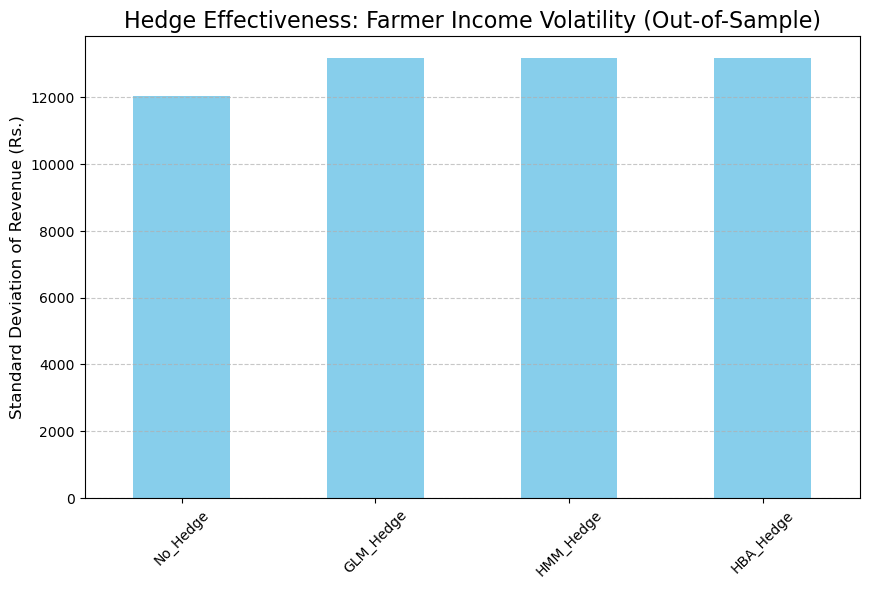


--- Basis Risk Analysis (on Test Set) ---
Payout?       False  True 
Actual Loss?              
False             2      1
True              1      3

--- Matrix Interpretation ---
  True Positives (Good): 3
  False Positives (Bad): 1 (Windfall)
  False Negatives (Bad): 1 (Basis Risk - Hedge Failed)
  True Negatives (Good): 2

  Precision (of payouts, how many were useful?): 0.75
  Recall (of losses, how many were covered?): 0.75
  F1-Score (balance of Precision/Recall): 0.75

Total time taken: 0.16 seconds


In [4]:
# -------------------------------------------------------------------
# CHAPTER 3.4.3: THE FINANCIAL BACKTEST (Corrected v3 - Final)
# -------------------------------------------------------------------
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import nnls # For the two-tick regression
import time # --- THIS IS THE FIX ---

print("--- Backtest Script (Advanced v3) ---")
start_time = time.time()

# --- 1. Define File Names and Parameters ---
FINAL_INDEX_FILE = 'final_index_series.csv'
YIELD_FILE = 'kanker_yield.csv'
YIELD_FILE_DETRENDED = 'kanker_yield_detrended.csv'

# --- Economic Parameters ---
PRICE_OF_RICE = 21830  # Rs/Tonne (MSP for 2023-24)
SPLIT_YEAR = 2016      # The year our TEST set begins

# --- Raw Model Prices (from your previous runs) ---
TICK_OLD = 1000.0        # The placeholder tick you used to get these prices
HBA_PRICE_raw = 25336.50
GLM_PRICE_raw = 43715.89
HMM_PRICE_raw = 39045.76 # Use your most recent, stable HMM price

# --- Derivative Parameters (We will set these on the TRAINING set) ---
STRIKE_K1_PERCENTILE = 0.30  # 30th
STRIKE_K2_PERCENTILE = 0.90  # 90th
DISCOUNT_RATE = 0.065
TIME_TO_MATURITY_T = 1.0 

print("Parameters set. Loading data...")

# --- 2. Load and Split Data ---
try:
    index_df = pd.read_csv(FINAL_INDEX_FILE)
    yield_df = pd.read_csv(YIELD_FILE)
    yield_detrended_df = pd.read_csv(YIELD_FILE_DETRENDED)
except FileNotFoundError as e:
    print(f"--- ERROR: {e} ---")

master_df = pd.merge(index_df, yield_df, on='Year')
master_df = pd.merge(master_df, yield_detrended_df, on='Year')
print(f"Data merged. {len(master_df)} total years.")

train_df = master_df[master_df['Year'] < SPLIT_YEAR].copy()
test_df = master_df[master_df['Year'] >= SPLIT_YEAR].copy()
print(f"Training on {len(train_df)} years. Testing on {len(test_df)} years.")

# --- 3. Calculate Parameters on TRAINING Data ONLY ---
print("\n--- Calculating All Parameters on TRAINING Data ---")

# 3a. Calculate Strikes
K1_drought_strike = np.percentile(train_df['Index_Value_mm'], STRIKE_K1_PERCENTILE * 100)
K2_flood_strike = np.percentile(train_df['Index_Value_mm'], STRIKE_K2_PERCENTILE * 100)
print(f"  Strikes (Train-set): K1={K1_drought_strike:.2f} mm, K2={K2_flood_strike:.2f} mm")

# 3b. Calculate Two-Tick "Economic Hedge" (Hedge Regression)
R_tr = train_df['Index_Value_mm'].values
dry_mm_tr = np.maximum(K1_drought_strike - R_tr, 0.0)
flood_mm_tr = np.maximum(R_tr - K2_flood_strike, 0.0)
y_loss_rs_tr = -PRICE_OF_RICE * train_df['Yield_Detrended'].values
X_tr = np.column_stack([dry_mm_tr, flood_mm_tr])

q_hat, _ = nnls(X_tr, y_loss_rs_tr)
q_dry, q_wet = q_hat
print(f"  Calibrated Ticks (Train-set): q_dry=Rs.{q_dry:.2f}/mm, q_wet=Rs.{q_wet:.2f}/mm")

# 3c. Rescale Premiums
ECONOMIC_TICK_VALUE_AVG = (q_dry + q_wet) / 2 
scale = ECONOMIC_TICK_VALUE_AVG / TICK_OLD
# Add a check for zero or NaN scale to prevent errors
if scale > 0:
    print(f"\nRescaling premiums by average tick factor x{scale:.4f}...")
    HBA_PREMIUM = HBA_PRICE_raw * scale
    GLM_PREMIUM = GLM_PRICE_raw * scale
    HMM_PREMIUM = HMM_PRICE_raw * scale
else:
    print("\nWarning: Economic ticks are zero. Using raw (unscaled) premiums.")
    HBA_PREMIUM = HBA_PRICE_raw
    GLM_PREMIUM = GLM_PRICE_raw
    HMM_PREMIUM = HMM_PRICE_raw

print(f"  New HBA Premium: Rs.{HBA_PREMIUM:,.2f}")
print(f"  New GLM Premium: Rs.{GLM_PREMIUM:,.2f}")
print(f"  New HMM Premium: Rs.{HMM_PREMIUM:,.2f}")

# --- 4. Run Backtest on TEST Data ONLY ---
print("\n--- Running Backtest on TEST Data (Out-of-Sample) ---")

R_te = test_df['Index_Value_mm'].values
dry_mm_te = np.maximum(K1_drought_strike - R_te, 0.0)
flood_mm_te = np.maximum(R_te - K2_flood_strike, 0.0)

test_df['Historical_Payoff_Rs'] = dry_mm_te * q_dry + flood_mm_te * q_wet

test_df['Revenue_NoHedge'] = test_df['Yield'] * PRICE_OF_RICE
test_df['Revenue_HBA'] = test_df['Revenue_NoHedge'] + test_df['Historical_Payoff_Rs'] - HBA_PREMIUM
test_df['Revenue_GLM'] = test_df['Revenue_NoHedge'] + test_df['Historical_Payoff_Rs'] - GLM_PREMIUM
test_df['Revenue_HMM'] = test_df['Revenue_NoHedge'] + test_df['Historical_Payoff_Rs'] - HMM_PREMIUM

print("Backtest simulation complete.")

# --- 5. Calculate Final Metrics (on TEST Data) ---
def scenario_metrics(df, label):
    m = {}
    m['Mean Revenue'] = df.mean()
    m['Std Dev'] = df.std(ddof=1)
    m['Min Revenue (Worst Year)'] = df.min()
    return pd.Series(m, name=label)

results = pd.concat([
    scenario_metrics(test_df['Revenue_NoHedge'], 'No_Hedge'),
    scenario_metrics(test_df['Revenue_HBA'], 'HBA_Hedge'),
    scenario_metrics(test_df['Revenue_GLM'], 'GLM_Hedge'),
    scenario_metrics(test_df['Revenue_HMM'], 'HMM_Hedge')
], axis=1).T

base_var = results.loc['No_Hedge', 'Std Dev']**2
results['Ederington_Effectiveness'] = 1.0 - (results['Std Dev']**2 / base_var)

print("\n--- !!! FINAL OUT-OF-SAMPLE BACKTEST RESULTS !!! ---")
print(results.to_markdown(floatfmt=",.2f"))

# --- 6. Plot the Results ---
print("\nPlotting Revenue Volatility (on Test Set)...")
results_sorted = results.sort_values(by='Std Dev')
plt.figure(figsize=(10, 6))
results_sorted['Std Dev'].plot(kind='bar', color='skyblue')
plt.title('Hedge Effectiveness: Farmer Income Volatility (Out-of-Sample)', fontsize=16)
plt.ylabel('Standard Deviation of Revenue (Rs.)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# --- 7. Basis Risk Diagnostics (on TEST Data) ---
print("\n--- Basis Risk Analysis (on Test Set) ---")
loss = test_df['Yield_Detrended'] < 0
payout = test_df['Historical_Payoff_Rs'] > 0

cm = pd.crosstab(loss, payout, rownames=['Actual Loss?'], colnames=['Payout?'])
print(cm)

TP = cm.loc[True, True]   if (True in cm.index and True in cm.columns)  else 0
FP = cm.loc[False, True]  if (False in cm.index and True in cm.columns) else 0
FN = cm.loc[True, False]  if (True in cm.index and False in cm.columns) else 0
TN = cm.loc[False, False] if (False in cm.index and False in cm.columns) else 0

precision = TP / (TP + FP) if (TP+FP) > 0 else 0.0
recall    = TP / (TP + FN) if (TP+FN) > 0 else 0.0
f1        = 2 * precision * recall / (precision + recall) if (precision+recall) > 0 else 0.0

print("\n--- Matrix Interpretation ---")
print(f"  True Positives (Good): {TP}")
print(f"  False Positives (Bad): {FP} (Windfall)")
print(f"  False Negatives (Bad): {FN} (Basis Risk - Hedge Failed)")
print(f"  True Negatives (Good): {TN}")

print(f"\n  Precision (of payouts, how many were useful?): {precision:.2f}")
print(f"  Recall (of losses, how many were covered?): {recall:.2f}")
print(f"  F1-Score (balance of Precision/Recall): {f1:.2f}")

end_time = time.time()
print(f"\nTotal time taken: {end_time - start_time:.2f} seconds")